1. 5분위 NAV, 로그수익률
2. 히트맵 샤프
3. 롱-온리 NAV, 로그 수익률
4. 롱-숏 NAV, 로그 수익률
5. 거래비용..

포트폴리오 NAV, 로그누적수익률 계산

In [19]:
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm

# =========================
# 1) 파일 경로
# =========================
portfolio_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\5분위_portfolio_return_all.csv"
factors_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\11_메인세션 1주차 (26.03.13)\01_Advanced Backtesting\1. Factor Construction\output\factors quarterly.csv"

# =========================
# 2) 데이터 로드
# =========================
port_df = pd.read_csv(portfolio_path)
fac_df = pd.read_csv(factors_path)

port_df["Date"] = pd.to_datetime(port_df["Date"])
fac_df["Date"] = pd.to_datetime(fac_df["Date"])

# =========================
# 3) 포트폴리오 컬럼 파싱
#    예: Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)
# =========================
value_cols = [c for c in port_df.columns if c != "Date"]

long_df = port_df.melt(
    id_vars="Date",
    value_vars=value_cols,
    var_name="portfolio_col",
    value_name="ret"
)

pattern = re.compile(r"^(?P<strategy>.+)_Q\((?P<q>[1-5])/5\)$")
parsed = long_df["portfolio_col"].str.extract(pattern)

long_df = pd.concat([long_df, parsed], axis=1).dropna(subset=["strategy", "q"])
long_df["q"] = long_df["q"].astype(int)

# =========================
# 4) 팩터 병합
# =========================
use_fac_cols = ["Date", "KOSPI", "SMB", "HML", "MOM", "RF"]
merged = long_df.merge(fac_df[use_fac_cols], on="Date", how="inner").dropna()

# =========================
# 5) 성과지표 함수
#    - 본 CSV는 실제 실현 수익률만 저장되어 있으므로
#      첫 관측치를 버리지 않고 전체 구간으로 계산
# =========================
def sharpe_ratio_module_style(returns: pd.Series, periods_per_year: int = 4):
    r = returns.dropna()
    if len(r) < 2:
        return np.nan

    vol_quarterly = r.std()  # pandas 기본(ddof=1)
    vol_annual = vol_quarterly * np.sqrt(periods_per_year)
    mean_return_quarterly = r.mean()

    if vol_annual == 0:
        return np.nan

    return (mean_return_quarterly * periods_per_year) / vol_annual


def cagr_from_returns(returns: pd.Series, periods_per_year: int = 4):
    r = returns.dropna()
    if len(r) == 0:
        return np.nan

    nav = (1 + r).cumprod()
    initial_nav = 1.0
    final_nav = nav.iloc[-1]

    years = len(r) / periods_per_year
    if years <= 0 or final_nav <= 0:
        return np.nan

    return (final_nav / initial_nav) ** (1 / years) - 1


def annualized_volatility(returns: pd.Series, periods_per_year: int = 4):
    r = returns.dropna()
    if len(r) < 2:
        return np.nan

    return r.std() * np.sqrt(periods_per_year)


# =========================
# 6) 회귀 + 성과지표 계산
#    y = (portfolio return - RF)
#    X = [const, KOSPI, SMB, HML, MOM]
# =========================
results = []

for (strategy, q), g in merged.groupby(["strategy", "q"], sort=True):
    g = g.dropna(subset=["ret", "RF", "KOSPI", "SMB", "HML", "MOM"]).copy()
    if len(g) < 8:  # 표본이 너무 적으면 skip
        continue

    y = g["ret"] - g["RF"]
    X = sm.add_constant(g[["KOSPI", "SMB", "HML", "MOM"]])
    model = sm.OLS(y, X).fit()

    alpha_q = model.params.get("const", np.nan)
    alpha_ann = alpha_q * 4 if pd.notna(alpha_q) else np.nan
    alpha_t = model.tvalues.get("const", np.nan)
    alpha_p = model.pvalues.get("const", np.nan)

    ret_series = g["ret"]
    cagr = cagr_from_returns(ret_series, periods_per_year=4)
    vol_ann = annualized_volatility(ret_series, periods_per_year=4)
    sharpe = sharpe_ratio_module_style(ret_series, periods_per_year=4)

    results.append({
        "strategy": strategy,
        "quintile": q,
        "n_obs": len(g),
        "alpha_quarterly": alpha_q,
        "alpha_annualized": alpha_ann,
        "alpha_tstat": alpha_t,
        "alpha_pvalue": alpha_p,
        "CAGR": cagr,
        "Volatility (ann.)": vol_ann,
        "sharpe_ratio": sharpe,
    })

res_df = pd.DataFrame(results).sort_values(["strategy", "quintile"]).reset_index(drop=True)

pd.set_option("display.float_format", "{:.6f}".format)
print(res_df)

out_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\quintile_alpha_sharpe.csv"
res_df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"saved: {out_path}")

                        strategy  quintile  n_obs  alpha_quarterly  \
0       Cap_R0.01_H0L0_T0.1_A0.2         1     79         0.012761   
1       Cap_R0.01_H0L0_T0.1_A0.2         2     79        -0.009750   
2       Cap_R0.01_H0L0_T0.1_A0.2         3     79        -0.003076   
3       Cap_R0.01_H0L0_T0.1_A0.2         4     79        -0.014351   
4       Cap_R0.01_H0L0_T0.1_A0.2         5     79        -0.024567   
5     Cap_R0.01_H80L30_T0.1_A0.2         1     79         0.012294   
6     Cap_R0.01_H80L30_T0.1_A0.2         2     79        -0.011210   
7     Cap_R0.01_H80L30_T0.1_A0.2         3     79        -0.004924   
8     Cap_R0.01_H80L30_T0.1_A0.2         4     79        -0.016205   
9     Cap_R0.01_H80L30_T0.1_A0.2         5     79        -0.026036   
10    Equal_R0.01_H0L0_T0.1_A0.2         1     79         0.008789   
11    Equal_R0.01_H0L0_T0.1_A0.2         2     79         0.007862   
12    Equal_R0.01_H0L0_T0.1_A0.2         3     79         0.007611   
13    Equal_R0.01_H0

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path

# 경로 설정
BASE = Path(r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term")

FILES = {
    "quintile": BASE / "5분위_portfolio_return_all.csv",
    "double_sort_25": BASE / "double_sort_portfolio_cap_return_25.csv",
    "spread": BASE / "spread_portfolio_return.csv",
}

OUT_DIR = BASE  # 같은 폴더에 저장; 바꾸려면 수정


def enrich_nav_log_cum(df: pd.DataFrame, date_col: str = "Date") -> pd.DataFrame:
    """수익률 열에 대해 NAV, 로그 누적수익률 열을 추가한 wide DataFrame 반환."""
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    out = out.sort_values(date_col).reset_index(drop=True)

    ret_cols = [c for c in out.columns if c != date_col]

    for c in ret_cols:
        r = pd.to_numeric(out[c], errors="coerce")
        # 1+r <= 0 이면 log 불가 — 해당 구간은 NaN 처리
        gross = 1.0 + r
        nav = gross.cumprod()
        log_cum = np.where(gross > 0, np.log(gross).cumsum(), np.nan)

        out[f"NAV_{c}"] = nav
        out[f"log_cum_{c}"] = log_cum

    return out


def main():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    for name, path in FILES.items():
        df = pd.read_csv(path)
        enriched = enrich_nav_log_cum(df)
        out_path = OUT_DIR / f"{path.stem}_nav_log_cum.csv"
        enriched.to_csv(out_path, index=False)
        print(f"saved: {out_path}")


if __name__ == "__main__":
    main()

saved: c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\5분위_portfolio_return_all_nav_log_cum.csv
saved: c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\double_sort_portfolio_cap_return_25_nav_log_cum.csv
saved: c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\spread_portfolio_return_nav_log_cum.csv


히트맵 샤프 비율

In [21]:
import numpy as np
import pandas as pd
import plotly.express as px

# 경로는 노트북 위치에 맞게 조정
PATH = "./01_output/01_quarterly/02_short_term/double_sort_portfolio_cap_return_25.csv"

PERIODS_PER_YEAR = 4  # module_quarter.performance_metrics 와 동일 (분기)


def sharpe_ratio_quarterly(series: pd.Series) -> float:
    """module_quarter.performance_metrics 와 동일 정의 (Rf=0, 분기→연율화)."""
    r = pd.to_numeric(series, errors="coerce").dropna()
    if r.empty:
        return np.nan
    mean_q = r.mean()
    vol_q = r.std()
    vol_ann = vol_q * np.sqrt(PERIODS_PER_YEAR)
    if vol_ann == 0:
        return np.nan
    return (mean_q * PERIODS_PER_YEAR) / vol_ann


# 1) 수익률 로드 (Date 인덱스)
df = pd.read_csv(PATH, parse_dates=["Date"]).set_index("Date").sort_index()

# 2) 열별 샤프 → MultiIndex → 5×5 (노트북 CAGR 히트맵과 동일 패턴)
sharpes = df.apply(sharpe_ratio_quarterly)
sharpes.index = sharpes.index.str.split("_", expand=True)
sharpes.index.names = ["C", "Q"]
sharpe_matrix = sharpes.unstack()  # 행: C, 열: Q

# 3) 시각화 (CAGR 셀과 동일하게 px.imshow)
fig = px.imshow(
    sharpe_matrix,
    text_auto=".2f",
    color_continuous_scale="YlOrRd",
    aspect="equal",
    title="Sharpe Ratio Heatmap by Cap vs Factor Quintile",
    width=600,
    height=600,
    labels=dict(x="Factor Quintile (Q)", y="Market Cap Quintile (C)", color="Sharpe"),
)
fig.update_yaxes(autorange="reversed")
fig.update_traces(textfont=dict(size=25))  # ← 이 줄 추가
fig.show()

롱숏 포트폴리오

saved: ./01_output/01_quarterly/02_short_term/5분위_long_short_returns_cap.csv
            Cap_R0.01_H80L30_T0.1_A0.2_LS  Cap_R0.01_H0L0_T0.1_A0.2_LS
Date                                                                  
2006-06-30                       0.024054                     0.023991
2006-09-30                       0.009193                     0.008543
2006-12-31                       0.024295                     0.021879
2007-03-31                      -0.070611                    -0.072207
2007-06-30                      -0.056944                    -0.060965


<Axes: xlabel='Date'>

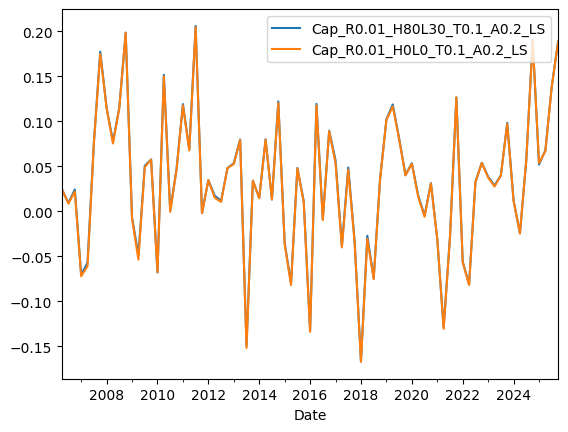

In [22]:
import pandas as pd

PATH = "./01_output/01_quarterly/02_short_term/5분위_portfolio_return_all.csv"
OUT_PATH = "./01_output/01_quarterly/02_short_term/5분위_long_short_returns_cap.csv"

df = pd.read_csv(PATH, parse_dates=["Date"]).sort_values("Date")

# 시가총액(Cap) 포트폴리오의 1분위(Q1)만 선택한 뒤 같은 설정의 5분위(Q5)와 매칭
q1_cols = [
    c for c in df.columns
    if c != "Date" and c.startswith("Cap_") and c.endswith("Q(1/5)")
]

long_short = pd.DataFrame({"Date": df["Date"]})
for c1 in q1_cols:
    c5 = c1.replace("Q(1/5)", "Q(5/5)")
    if c5 not in df.columns:
        continue
    prefix = c1[: -len("_Q(1/5)")]
    # 롱숏 수익률 = 1분위(롱) - 5분위(숏)
    long_short[f"{prefix}_LS"] = df[c1] - df[c5]

# long_short: Date 인덱스, 열 = Cap 기준 롱숏 분기 수익률
long_short = long_short.set_index("Date")
long_short.to_csv(OUT_PATH)

print(f"saved: {OUT_PATH}")
print(long_short.head())
long_short.plot()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# long_short: Date 인덱스, 열 = 분기 수익률 (이미 있다면 그대로 사용)
# 예: long_short = pd.read_csv("...long_short....csv", parse_dates=["Date"], index_col="Date")

returns = long_short.sort_index()
nav = (1 + returns).cumprod()
nav.columns = [f"NAV_{c}" if not str(c).startswith("NAV_") else c for c in nav.columns]

import plotly.graph_objects as go

fig = go.Figure()
for col in nav.columns:
    fig.add_trace(go.Scatter(x=nav.index, y=nav[col], mode="lines", name=col))
fig.update_layout(
    title="Long–Short portfolio NAV (base = 1)",
    xaxis_title="Date",
    yaxis_title="NAV",
    height=500,
    legend=dict(font=dict(size=8)),
)
fig.show()

롱숏 포트폴리오 성과지표

In [24]:
import numpy as np
import pandas as pd

PERIODS_PER_YEAR = 4  # 분기


def quarterly_performance_metrics(returns: pd.Series) -> dict:
    """
    module_quarter.performance_metrics 와 동일한 샤프/변동성 정의.
    CAGR: 초기 NAV=1, 분기 수익률 n개 → 연환산 복리.
    """
    r = pd.to_numeric(returns, errors="coerce").dropna()
    if r.empty:
        return {
            "CAGR": np.nan,
            "Volatility (ann.)": np.nan,
            "Sharpe Ratio": np.nan,
            "MDD": np.nan,
            "n_quarters": 0,
        }

    nav = (1 + r).cumprod()
    initial_nav = 1.0
    final_nav = nav.iloc[-1]
    n = len(r)
    years = n / PERIODS_PER_YEAR
    cagr = (final_nav / initial_nav) ** (1 / years) - 1 if years > 0 else np.nan

    vol_q = r.std()
    vol_ann = vol_q * np.sqrt(PERIODS_PER_YEAR)
    sharpe = (r.mean() * PERIODS_PER_YEAR) / vol_ann if vol_ann != 0 else np.nan

    cummax = nav.cummax()
    mdd = (nav / cummax - 1).min()

    return {
        "CAGR": cagr,
        "Volatility (ann.)": vol_ann,
        "Sharpe Ratio": sharpe,
        "MDD": mdd,
        "n_quarters": n,
    }


# long_short: Date 인덱스, 열 = 분기 롱숏 수익률
returns = long_short.sort_index()

perf_rows = []
for col in returns.columns:
    m = quarterly_performance_metrics(returns[col])
    m["portfolio"] = col
    perf_rows.append(m)

perf_df = pd.DataFrame(perf_rows).set_index("portfolio")
# 보기 좋게 열 순서
cols = ["n_quarters", "CAGR", "Volatility (ann.)", "Sharpe Ratio", "MDD"]
perf_df = perf_df[[c for c in cols if c in perf_df.columns]]

display(perf_df)  # Jupyter
# perf_df.to_csv("01_output/.../long_short_performance.csv")

,n_quarters,CAGR,Volatility (ann.),Sharpe Ratio,MDD
portfolio,,,,,
Cap_R0.01_H80L30_T0.1_A0.2_LS,79,0.128222,0.157345,0.854665,-0.274835
Cap_R0.01_H0L0_T0.1_A0.2_LS,79,0.123461,0.157607,0.825965,-0.279554


KOSPI NAV, 누적수익률

In [25]:
import numpy as np
import pandas as pd
from pathlib import Path

IN_PATH = Path(
    r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\00_input\factors quarterly.csv"
)
OUT_PATH = IN_PATH.parent / "KOSPI_nav_log_quarterly.csv"  # 저장 위치·이름은 원하는 대로

df = pd.read_csv(IN_PATH, parse_dates=["Date"]).sort_values("Date")

r = pd.to_numeric(df["KOSPI"], errors="coerce")
gross = 1.0 + r

out = pd.DataFrame({
    "Date": df["Date"],
    "KOSPI_return": r,
    "NAV_KOSPI": gross.cumprod(),
    "log_ret_KOSPI": np.where(gross > 0, np.log(gross), np.nan),
})
out["log_cum_KOSPI"] = out["log_ret_KOSPI"].cumsum()

out.to_csv(OUT_PATH, index=False)
print(f"saved: {OUT_PATH}")

saved: c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\00_input\KOSPI_nav_log_quarterly.csv


In [26]:
import numpy as np
import pandas as pd
from pathlib import Path

from module_quarter import performance_metrics

BASE = Path("./01_output/01_quarterly/02_short_term")  # 노트북 위치에 맞게 수정

PAIRS = [
    {
        "source": "quintile",
        "returns": BASE / "5분위_portfolio_return_all.csv",
        "trades": BASE / "5분위_total_trade_all.csv",
    },
    {
        "source": "double_sort_25",
        "returns": BASE / "double_sort_portfolio_cap_return_25.csv",
        "trades": BASE / "double_sort_total_trade_cap_25.csv",
    },
]


def returns_and_trade_to_portfolio_df(
    r: pd.Series, t: pd.Series
) -> pd.DataFrame:
    """
    같은 Date 인덱스의 분기 수익률 r, 총거래(Trade) t.
    performance_metrics는 Trade.iloc[1:]만 사용하므로, 맨 앞 행 Trade는 더미(0).
    """
    df = pd.concat([r.rename("Return"), t.rename("Trade")], axis=1).dropna()
    if df.empty:
        return pd.DataFrame({"NAV": [1.0], "Return": [np.nan], "Trade": [0.0]})

    r = df["Return"].to_numpy(dtype=float)
    tr = df["Trade"].to_numpy(dtype=float)

    nav = np.concatenate([[1.0], np.cumprod(1.0 + r)])
    ret = np.concatenate([[np.nan], r])
    trade = np.concatenate([[0.0], tr])

    return pd.DataFrame({"NAV": nav, "Return": ret, "Trade": trade})


def load_aligned_ret_trade(ret_path: Path, trade_path: Path):
    ret = pd.read_csv(ret_path, parse_dates=["Date"]).set_index("Date").sort_index()
    trd = pd.read_csv(trade_path, parse_dates=["Date"]).set_index("Date").sort_index()
    common = ret.index.intersection(trd.index)
    return ret.loc[common], trd.loc[common]


def all_portfolio_metrics_with_turnover(
    ret_df: pd.DataFrame, trd_df: pd.DataFrame, source_name: str
) -> pd.DataFrame:
    ret_cols = [c for c in ret_df.columns if c in trd_df.columns]
    rows = []
    for col in ret_cols:
        port = returns_and_trade_to_portfolio_df(ret_df[col], trd_df[col])
        m = performance_metrics(port)
        m["source"] = source_name
        m["portfolio"] = col
        rows.append(m)
    return pd.DataFrame(rows)


tables = []
for p in PAIRS:
    rdf, tdf = load_aligned_ret_trade(p["returns"], p["trades"])
    tables.append(all_portfolio_metrics_with_turnover(rdf, tdf, p["source"]))

perf_all = pd.concat(tables, ignore_index=True)
display(perf_all)
perf_all.to_csv(BASE / "portfolio_performance_with_turnover.csv", index=False)

,CAGR,Volatility (ann.),Sharpe Ratio,MDD,Average Turnover (quarterly),source,portfolio
0,0.092449,0.206904,0.531713,-0.471817,0.423663,quintile,Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)
1,0.094323,0.212737,0.532057,-0.490659,0.684138,quintile,Equal_R0.01_H80L30_T0.1_A0.2_Q(2/5)
2,0.093929,0.228384,0.508135,-0.513568,0.773497,quintile,Equal_R0.01_H80L30_T0.1_A0.2_Q(3/5)
3,0.050076,0.227861,0.328260,-0.579150,0.731802,quintile,Equal_R0.01_H80L30_T0.1_A0.2_Q(4/5)
4,-0.090554,0.242360,-0.260086,-0.879569,0.542573,quintile,Equal_R0.01_H80L30_T0.1_A0.2_Q(5/5)
5,0.099320,0.207318,0.561816,-0.467354,0.423663,quintile,Equal_R0.01_H0L0_T0.1_A0.2_Q(1/5)
6,0.105547,0.213590,0.579375,-0.484057,0.684138,quintile,Equal_R0.01_H0L0_T0.1_A0.2_Q(2/5)
7,0.107061,0.229310,0.559899,-0.506177,0.773497,quintile,Equal_R0.01_H0L0_T0.1_A0.2_Q(3/5)
8,0.062580,0.228810,0.379908,-0.573295,0.731802,quintile,Equal_R0.01_H0L0_T0.1_A0.2_Q(4/5)
9,-0.082075,0.243136,-0.221410,-0.871916,0.542573,quintile,Equal_R0.01_H0L0_T0.1_A0.2_Q(5/5)


### KOSPI 분기별 누적수익률, 로그누적수익률

In [27]:
import pandas as pd
import numpy as np

PATH = r"c:\Users\XH58\Desktop\Quantifi\01_2025-2\02_메인 세션\Residual_MAX\Residual_MAX\KOSPI_KOSDAQ\input\preprocessing\KOSPI_index.csv"
start_date = "2006-03-31"
end_date = "2025-12-31"

# 1) 로드
df = pd.read_csv(PATH, parse_dates=["Date"])
df["KOSPI"] = pd.to_numeric(df["KOSPI"], errors="coerce")
df = df.dropna(subset=["KOSPI"]).set_index("Date").sort_index()

# 2) 분기말 수준(캘린더 분기: Q-DEC => 3/31, 6/30, 9/30, 12/31)
q = df.loc[start_date:end_date, "KOSPI"].resample("QE").last()
q = q.loc[start_date:end_date]  # 분기 인덱스 범위 정리

# 3) 기준(2006-03-31)
base = q.loc[pd.Timestamp(start_date)]

# 4) 분기별 누적수익률(배) & 로그누적수익률
q_df = pd.DataFrame(index=q.index)
q_df["KOSPI"] = q.values
q_df["누적수익률(배)"] = q_df["KOSPI"] / base
q_df["누적수익률(%)"] = (q_df["누적수익률(배)"] - 1) * 100
q_df["로그누적수익률"] = np.log(q_df["누적수익률(배)"])  # log(KOSPI/base)

# (옵션) 실제 분기별 “수익률”도 필요하면 추가
q_df["분기수익률(%)"] = q_df["KOSPI"].pct_change() * 100

q_df.to_csv(r"KOSPI_quarter_cum_returns_20060331_20251231.csv", index=True, encoding="utf-8-sig")

### 5분위 포트폴리오 성과 지표, 알파

In [28]:
import re
import numpy as np
import pandas as pd
import statsmodels.api as sm

# =========================
# 1) 파일 경로
# =========================
portfolio_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\5분위_portfolio_return_all.csv"
factors_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\11_메인세션 1주차 (26.03.13)\01_Advanced Backtesting\1. Factor Construction\output\factors quarterly.csv"

# =========================
# 2) 데이터 로드
# =========================
port_df = pd.read_csv(portfolio_path)
fac_df = pd.read_csv(factors_path)

port_df["Date"] = pd.to_datetime(port_df["Date"])
fac_df["Date"] = pd.to_datetime(fac_df["Date"])

# =========================
# 3) 포트폴리오 컬럼 파싱
#    예: Equal_R0.01_H80L30_T0.1_A0.2_Q(1/5)
# =========================
value_cols = [c for c in port_df.columns if c != "Date"]

long_df = port_df.melt(
    id_vars="Date",
    value_vars=value_cols,
    var_name="portfolio_col",
    value_name="ret"
)

pattern = re.compile(r"^(?P<strategy>.+)_Q\((?P<q>[1-5])/5\)$")
parsed = long_df["portfolio_col"].str.extract(pattern)

long_df = pd.concat([long_df, parsed], axis=1).dropna(subset=["strategy", "q"])
long_df["q"] = long_df["q"].astype(int)

# =========================
# 4) 팩터 병합
# =========================
use_fac_cols = ["Date", "KOSPI", "SMB", "HML", "MOM", "RF"]
merged = long_df.merge(fac_df[use_fac_cols], on="Date", how="inner").dropna()

# =========================
# 5) 샤프지수 (module_quarter.py 방식)
# =========================
def sharpe_ratio_module_style(returns: pd.Series, periods_per_year: int = 4):
    r = returns.dropna()
    if len(r) < 2:
        return np.nan

    vol_quarterly = r.std(ddof=1)
    vol_annual = vol_quarterly * np.sqrt(periods_per_year)
    mean_return_quarterly = r.mean()

    if vol_annual == 0:
        return np.nan

    return (mean_return_quarterly * periods_per_year) / vol_annual

# =========================
# 6) 회귀 + 샤프 계산
#    y = (portfolio return - RF)
#    X = [const, KOSPI, SMB, HML, MOM]
# =========================
results = []

for (strategy, q), g in merged.groupby(["strategy", "q"], sort=True):
    g = g.dropna(subset=["ret", "RF", "KOSPI", "SMB", "HML", "MOM"]).copy()
    if len(g) < 8:  # 표본이 너무 적으면 skip
        continue

    # 회귀용 초과수익률
    y = g["ret"] - g["RF"]
    X = sm.add_constant(g[["KOSPI", "SMB", "HML", "MOM"]])

    model = sm.OLS(y, X).fit()

    alpha_q = model.params.get("const", np.nan)              # 분기 알파
    alpha_ann = alpha_q * 4 if pd.notna(alpha_q) else np.nan # 연율 알파(단순 *4)
    alpha_t = model.tvalues.get("const", np.nan)
    alpha_p = model.pvalues.get("const", np.nan)

    sharpe = sharpe_ratio_module_style(g["ret"], periods_per_year=4)

    results.append({
        "strategy": strategy,
        "quintile": q,
        "n_obs": len(g),
        "alpha_quarterly": alpha_q,
        "alpha_annualized": alpha_ann,
        "alpha_tstat": alpha_t,
        "alpha_pvalue": alpha_p,
        "sharpe_ratio": sharpe,
    })

res_df = pd.DataFrame(results).sort_values(["strategy", "quintile"]).reset_index(drop=True)

# 보기 좋게 출력
pd.set_option("display.float_format", "{:.6f}".format)
print(res_df)

# 필요시 저장
out_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\quintile_alpha_sharpe.csv"
res_df.to_csv(out_path, index=False, encoding="utf-8-sig")

                        strategy  quintile  n_obs  alpha_quarterly  \
0       Cap_R0.01_H0L0_T0.1_A0.2         1     79         0.012761   
1       Cap_R0.01_H0L0_T0.1_A0.2         2     79        -0.009750   
2       Cap_R0.01_H0L0_T0.1_A0.2         3     79        -0.003076   
3       Cap_R0.01_H0L0_T0.1_A0.2         4     79        -0.014351   
4       Cap_R0.01_H0L0_T0.1_A0.2         5     79        -0.024567   
5     Cap_R0.01_H80L30_T0.1_A0.2         1     79         0.012294   
6     Cap_R0.01_H80L30_T0.1_A0.2         2     79        -0.011210   
7     Cap_R0.01_H80L30_T0.1_A0.2         3     79        -0.004924   
8     Cap_R0.01_H80L30_T0.1_A0.2         4     79        -0.016205   
9     Cap_R0.01_H80L30_T0.1_A0.2         5     79        -0.026036   
10    Equal_R0.01_H0L0_T0.1_A0.2         1     79         0.008789   
11    Equal_R0.01_H0L0_T0.1_A0.2         2     79         0.007862   
12    Equal_R0.01_H0L0_T0.1_A0.2         3     79         0.007611   
13    Equal_R0.01_H0

In [29]:
import statsmodels.api as sm
import pandas as pd

# merged: 이전 코드에서 만든 병합 데이터
# 컬럼: ['Date','portfolio_col','ret','strategy','q','KOSPI','SMB','HML','MOM','RF', ...]

def run_ols_for_portfolio(merged_df, strategy_name, quintile, use_excess_return=True):
    """
    strategy_name: 예) 'Equal_R0.01_H80L30_T0.1_A0.2'
    quintile: 1~5
    use_excess_return: True면 y = ret - RF, False면 y = ret
    """
    g = merged_df[(merged_df["strategy"] == strategy_name) & (merged_df["q"] == quintile)].copy()
    g = g.dropna(subset=["ret", "RF", "KOSPI", "SMB", "HML", "MOM"])

    if len(g) < 8:
        raise ValueError(f"표본이 너무 적습니다. n={len(g)}")

    y = g["ret"] - g["RF"] if use_excess_return else g["ret"]
    X = sm.add_constant(g[["KOSPI", "SMB", "HML", "MOM"]])

    model = sm.OLS(y, X).fit()
    return model, g


# =========================
# 1) 원하는 포트폴리오 지정
# =========================
target_strategy = "Cap_R0.01_H80L30_T0.1_A0.2"
target_q = 1

model, sample_df = run_ols_for_portfolio(
    merged_df=merged,
    strategy_name=target_strategy,
    quintile=target_q,
    use_excess_return=True
)

# =========================
# 2) OLS 전체 테이블 출력
# =========================
print(model.summary())

# =========================
# 3) 계수 테이블만 DataFrame으로 보기
# =========================
coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t": model.tvalues,
    "p_value": model.pvalues
})
print("\n[Coefficient Table]")
print(coef_table)

# =========================
# 4) 알파/샤프 같이 확인
# =========================
alpha_q = model.params["const"]
alpha_ann = alpha_q * 4

ret_series = sample_df["ret"]
vol_q = ret_series.std(ddof=1)
sharpe = (ret_series.mean() * 4) / (vol_q * (4 ** 0.5)) if vol_q != 0 else float("nan")

print(f"\nalpha_quarterly: {alpha_q:.6f}")
print(f"alpha_annualized: {alpha_ann:.6f}")
print(f"sharpe_ratio: {sharpe:.6f}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     136.4
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           2.42e-33
Time:                        05:44:38   Log-Likelihood:                 160.32
No. Observations:                  79   AIC:                            -310.6
Df Residuals:                      74   BIC:                            -298.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0123      0.004      3.057      0.0

롱 포트폴리오 OLS

In [30]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1) 경로
portfolio_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\double_sort_portfolio_cap_return_25.csv"
factors_path = r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\11_메인세션 1주차 (26.03.13)\01_Advanced Backtesting\1. Factor Construction\output\factors quarterly.csv"

target_col = "C(1/5)_Q(1/5)"  # 요청 포트폴리오

# 2) 데이터 로드
port_df = pd.read_csv(portfolio_path, parse_dates=["Date"])
fac_df = pd.read_csv(factors_path, parse_dates=["Date"])

# 3) 병합
use_fac_cols = ["Date", "KOSPI", "SMB", "HML", "MOM", "RF"]
merged = port_df[["Date", target_col]].merge(fac_df[use_fac_cols], on="Date", how="inner").dropna()

if len(merged) < 8:
    raise ValueError(f"표본 수가 너무 적습니다. n={len(merged)}")

# 4) 회귀: y = 포트폴리오 초과수익률, X = [const, KOSPI, SMB, HML, MOM]
y = merged[target_col] - merged["RF"]
X = sm.add_constant(merged[["KOSPI", "SMB", "HML", "MOM"]])

model = sm.OLS(y, X).fit()

# 5) 결과 출력
print(f"[Target Portfolio] {target_col}")
print(f"n_obs: {len(merged)}")
print(model.summary())

coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t": model.tvalues,
    "p_value": model.pvalues
})
print("\n[Coefficient Table]")
print(coef_table)

alpha_q = model.params.get("const", np.nan)
alpha_ann = alpha_q * 4 if pd.notna(alpha_q) else np.nan
print(f"\nalpha_quarterly: {alpha_q:.6f}")
print(f"alpha_annualized: {alpha_ann:.6f}")

[Target Portfolio] C(1/5)_Q(1/5)
n_obs: 79
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     105.3
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           9.29e-30
Time:                        05:44:38   Log-Likelihood:                 125.04
No. Observations:                  79   AIC:                            -240.1
Df Residuals:                      74   BIC:                            -228.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

### Residual_MAX(FF3) 스타일 롱숏 포트폴리오 (분기·제조업 profitability)

`KOSPI_KOSDAQ` 가격·거래대금·일간수익률은 `Residual_MAX` 입력을 쓰고, **팩터는 `00_input/profitability_제조업_분기_v3.csv`**, **리밸런싱은 분기말(`QE`)**입니다. 롱(하위 10%) / 숏(상위 10%)·거래비용·Amihud는 기존과 동일한 로직입니다. 경로는 환경에 맞게 수정하세요.

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd

# ----- 경로 (필요 시 수정) -----
RES_MAX_KQ = Path(
    r"c:\Users\XH58\Desktop\Quantifi\01_2025-2\02_메인 세션\Residual_MAX\Residual_MAX\KOSPI_KOSDAQ"
)
INPUT_DIR = RES_MAX_KQ / "input"
SESSION_INPUT = Path(
    r"c:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\00_input"
)

# 포트폴리오 수익률·시총·거래대금·일간수익률
total_adj_close = pd.read_csv(
    INPUT_DIR / "KOSPI_KOSDAQ_total_adj_close.csv", index_col=0, parse_dates=True
)
mkt_cap = pd.read_csv(
    INPUT_DIR / "KOSPI_KOSDAQ_mkt_cap.csv", index_col=0, parse_dates=True
)
trading_value_60 = pd.read_csv(
    INPUT_DIR / "KOSPI_KOSDAQ_trading_value_60.csv", index_col=0, parse_dates=True
)
daily_ret = pd.read_csv(
    INPUT_DIR / "KOSPI_KOSDAQ_daily_ret.csv", index_col=0, parse_dates=True
)
trading_value = pd.read_csv(
    INPUT_DIR / "KOSPI_KOSDAQ_trading_value.csv", index_col=0, parse_dates=True
)

# 제조업 분기 profitability 팩터
factor_df = pd.read_csv(
    SESSION_INPUT / "profitability_제조업_분기_v3.csv", index_col=0, parse_dates=True
)

# 분기 수익률 (`ret_m` 이름은 함수 내 그대로 사용)
ret_m = total_adj_close.resample("QE").last().ffill().pct_change()

start_point = "2000-01-01"
end_point = "2025-10-31"

quarter_ends = factor_df.resample("QE").last().index
quarter_ends = quarter_ends[
    (quarter_ends >= pd.to_datetime(start_point))
    & (quarter_ends <= pd.to_datetime(end_point))
]


def run_long_short_strategy(
    wins_threshold_temp,
    weight_method_temp,
    cost_temp,
    trading_threshold_temp,
    Amihud_threshold_temp,
    initial_NAV=1,
):
    high_cost, low_cost = cost_temp
    NAV = initial_NAV

    portfolio_name = (
        f"LongShort_R{wins_threshold_temp}_H{int(high_cost * 10000)}"
        f"L{int(low_cost * 10000)}_T{trading_threshold_temp}_A{Amihud_threshold_temp}"
    )
    portfolio_return = pd.Series(dtype=float, name=portfolio_name)
    total_trade = pd.Series(dtype=float, name=portfolio_name)

    ret_wins = ret_m.clip(
        lower=ret_m.quantile(wins_threshold_temp),
        upper=ret_m.quantile(1 - wins_threshold_temp),
        axis=1,
    )

    prev_portfolio_long = None
    prev_portfolio_short = None

    for i in range(len(quarter_ends) - 1):
        start_date, end_date = quarter_ends[i], quarter_ends[i + 1]

        series = trading_value_60.loc[start_date]
        threshold = series.quantile(trading_threshold_temp)
        filtered = series[series > threshold]
        factor_filtered = factor_df.loc[start_date, filtered.index]

        quantiles = pd.qcut(factor_filtered, q=10, labels=False, duplicates="drop")
        long_basket = factor_filtered[quantiles == 0]
        short_basket = factor_filtered[quantiles == 9]

        if long_basket.empty or short_basket.empty:
            continue

        illiq = daily_ret.loc[start_date].abs() / trading_value.loc[start_date]
        threshold = illiq.quantile(1 - Amihud_threshold_temp)
        illiquid_top = illiq[illiq >= threshold].index

        if prev_portfolio_long is None:
            prev_weights_long = pd.Series(0, index=long_basket.index)
        else:
            prev_weights_long = prev_portfolio_long / prev_portfolio_long.sum()

        if weight_method_temp == "Equal":
            target_weights_long = pd.Series(1 / len(long_basket), index=long_basket.index)
        else:
            cap_seg_long = mkt_cap.loc[start_date, long_basket.index]
            target_weights_long = cap_seg_long / cap_seg_long.sum()

        all_index_long = target_weights_long.index.union(prev_weights_long.index)
        target_w_long = target_weights_long.reindex(all_index_long, fill_value=0)
        prev_w_long = prev_weights_long.reindex(all_index_long, fill_value=0)
        delta_w_long = target_w_long - prev_w_long

        trade_amounts_long = abs(delta_w_long) * NAV / 2
        cost_rate_long = np.where(delta_w_long.index.isin(illiquid_top), high_cost, low_cost)
        trade_cost_long = (trade_amounts_long * cost_rate_long).sum()

        current_portfolio_value_long = target_weights_long * (NAV / 2 - trade_cost_long)
        ret_seg_long = ret_wins.loc[end_date, long_basket.index]
        next_portfolio_value_long = current_portfolio_value_long * (ret_seg_long + 1)

        if prev_portfolio_short is None:
            prev_weights_short = pd.Series(0, index=short_basket.index)
        else:
            prev_weights_short = prev_portfolio_short / prev_portfolio_short.sum()

        if weight_method_temp == "Equal":
            target_weights_short = pd.Series(1 / len(short_basket), index=short_basket.index)
        else:
            cap_seg_short = mkt_cap.loc[start_date, short_basket.index]
            target_weights_short = cap_seg_short / cap_seg_short.sum()

        all_index_short = target_weights_short.index.union(prev_weights_short.index)
        target_w_short = target_weights_short.reindex(all_index_short, fill_value=0)
        prev_w_short = prev_weights_short.reindex(all_index_short, fill_value=0)
        delta_w_short = target_w_short - prev_w_short

        trade_amounts_short = abs(delta_w_short) * NAV / 2
        cost_rate_short = np.where(delta_w_short.index.isin(illiquid_top), high_cost, low_cost)
        trade_cost_short = (trade_amounts_short * cost_rate_short).sum()

        current_portfolio_value_short = target_weights_short * (NAV / 2 - trade_cost_short)
        ret_seg_short = ret_wins.loc[end_date, short_basket.index]
        next_portfolio_value_short = current_portfolio_value_short * (1 - ret_seg_short)

        NAV_new_long = next_portfolio_value_long.sum()
        NAV_new_short = next_portfolio_value_short.sum()
        NAV_new = NAV_new_long + NAV_new_short

        portfolio_ret = NAV_new / NAV - 1

        prev_portfolio_long = next_portfolio_value_long
        prev_portfolio_short = next_portfolio_value_short
        NAV = NAV_new

        total_trade.loc[start_date] = trade_amounts_long.sum() + trade_amounts_short.sum()
        portfolio_return.loc[end_date] = portfolio_ret

    return portfolio_return, total_trade


def select_columns(df, fixed_options):
    selected = []
    new_names = {}

    for c in df.columns:
        parts = c.split("_")

        if all(parts[i] == v or v == "*" for i, v in fixed_options.items()):
            selected.append(c)
            free_parts = [parts[i] for i, v in fixed_options.items() if v == "*"]
            new_name = "_".join(free_parts)
            new_names[c] = new_name

    subset = df[selected].rename(columns=new_names)
    return subset


# ----- 예시 실행 -----
wins_threshold_temp = 0.01
weight_method_temp = "Cap"
cost_temp = (0.008, 0.003)
trading_threshold_temp = 0.1
Amihud_threshold_temp = 0.2

ls_ret, ls_trade = run_long_short_strategy(
    wins_threshold_temp,
    weight_method_temp,
    cost_temp,
    trading_threshold_temp,
    Amihud_threshold_temp,
    initial_NAV=1,
)

print(ls_ret.dropna().head())
print("n_quarters:", ls_ret.dropna().shape[0])

C:\Users\XH58\AppData\Local\Temp\ipykernel_95856\1070814945.py:37: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



KeyError: "['삼성화재', '미래에셋증권', '기업은행', 'DB손해보험', 'NH투자증권', '삼성증권', '신영증권', '현대해상', '코리안리', '대신증권', '한화투자증권', '교보증권', '유안타증권', '부국증권', '한화손해보험', '롯데손해보험', '현대차증권', '제주은행', '스틱인베스트먼트', 'DB증권', '유진투자증권', 'SK증권', '한양증권', '한국캐피탈', '흥국화재', '다올투자증권', '유화증권', '에이티넘인베스트', '제이준코스메틱', 'SBI인베스트먼트', '코웰패션', '대성창투', '상상인증권', '큐캐피탈', '플루토스', '신한은행', '우리은행', '메리츠화재', '동아건설', '해태제과', '삼환기업', '로케트전기', '제일화재', '리젠트화재', '서통', '우리증권', '서광건설', 'DL건설', '한보철강', '한국유리', '피어리스', '삼익건설', '알보젠코리아', 'KB손해보험', 'LGEI', '동양화학', '두산건설', '넥상스코리아', '대일화학', '알앤엘바이오', '신한증권', '하나증권', '현대증권', '대우', '삼양제넥스', '롯데미도파', '스마텔', '세신', '아이케이', '울트라건설', '오리온전기', '고합', '디와이홀딩스', '대우송도개발', '신동방CP', '보루네오', '렉스엘이앤지', '외환은행', '대우통신', '대구은행', '부산은행', '봉신', '신한', '광주은행', '동원증권', '성지건설', '한메NS', '극동전선', '인천정유', '전북은행', '경남은행', '유리이에스', '한솔아트원제지', '진흥저축은행', '하나은행.1', '대우전자', '해동금고', '태창기업', '폴루스바이오팜', '솔로몬저축은행', '한국협화', '세원화성', '도레이케미칼', '경남에너지', '산은캐피탈', 'C&중공업', '아이넥스', 'KEP전자', '일은증권', '메리츠증권', '굿모닝신한증권', 'i 인프라', '행남사', '동양현대종금', '중앙종금

### JMQ Cap 롱숏 포트폴리오

`Cap_R0.01_H80L30_T0.1_A0.2_Q(1/5)`를 롱, `Cap_R0.01_H80L30_T0.1_A0.2_Q(5/5)`를 숏으로 두는 분기 롱숏 포트폴리오입니다.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

portfolio_path = Path(
    r"C:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\5분위_portfolio_return_all.csv"
)
output_path = portfolio_path.with_name("long_short_portfolio_q1_minus_q5.csv")

long_col = "Cap_R0.01_H80L30_T0.1_A0.2_Q(1/5)"
short_col = "Cap_R0.01_H80L30_T0.1_A0.2_Q(5/5)"

# 1.0이면 Q1 - Q5 스프레드, 0.5면 롱 50% + 숏 50% 달러중립 포트폴리오
side_weight = 0.5
periods_per_year = 4

df = pd.read_csv(portfolio_path)
result = df[["Date", long_col, short_col]].copy()
result["Date"] = pd.to_datetime(result["Date"])
result = result.sort_values("Date").reset_index(drop=True)

result["long_return"] = result[long_col]
result["short_return_raw"] = result[short_col]
result["long_pnl"] = side_weight * result["long_return"]
result["short_pnl"] = -side_weight * result["short_return_raw"]
result["long_short_return"] = result["long_pnl"] + result["short_pnl"]
result["long_short_nav"] = (1 + result["long_short_return"]).cumprod()

result.to_csv(output_path, index=False, encoding="utf-8-sig")

ret = result["long_short_return"].dropna()
nav = (1 + ret).cumprod()
years = len(ret) / periods_per_year
cagr = nav.iloc[-1] ** (1 / years) - 1 if len(ret) > 0 and years > 0 else np.nan
vol_q = ret.std(ddof=1)
vol_ann = vol_q * np.sqrt(periods_per_year)
sharpe = ((ret.mean() * periods_per_year) / vol_ann) if vol_ann != 0 else np.nan
mdd = (nav / nav.cummax() - 1).min() if len(nav) > 0 else np.nan

display(result[["Date", "long_return", "short_return_raw", "long_short_return", "long_short_nav"]].head())
print(f"Saved: {output_path}")
print(f"CAGR: {cagr:.4f}")
print(f"Volatility (ann.): {vol_ann:.4f}")
print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"MDD: {mdd:.4f}")

,Date,long_return,short_return_raw,long_short_return,long_short_nav
0,2006-06-30,-0.024783,-0.048774,0.011996,1.011996
1,2006-09-30,0.052941,0.044399,0.004271,1.016318
2,2006-12-31,0.045614,0.023735,0.010940,1.027436
3,2007-03-31,-0.034314,0.037892,-0.036103,0.990342
4,2007-06-30,0.114352,0.175317,-0.030482,0.960154


Saved: C:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\02_전략 탐색\15_JMQ\01_output\01_quarterly\02_short_term\long_short_portfolio_q1_minus_q5.csv
CAGR: 0.0635
Volatility (ann.): 0.0788
Sharpe Ratio: 0.8260
MDD: -0.1468
